In [26]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_absolute_error, 
                           mean_squared_error, explained_variance_score)
from sklearn.inspection import permutation_importance
from scipy import stats
import os

In [27]:
MODEL_PATH = "../../../models/svr/svr_model_label_v3.joblib"  
DATA_PATH = "../../../data/preprocessed/selected_features_dataset.csv"

def load_model_and_data():
    """Load saved model and prepare data"""
    print("Loading model and data...")
    try:
        # Load model
        model = joblib.load(MODEL_PATH)
        print(f"Model loaded from {MODEL_PATH}")
        
        # Load and prepare data
        df = pd.read_csv(DATA_PATH)
        X = df.drop(['price_per_m2'], axis=1)
        y = df['price_per_m2']
        
        # Split data (use same random_state as training)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        return model, X_train, y_train, X_test, y_test, X.columns.tolist()
    
    except Exception as e:
        print(f"Error loading model or data: {str(e)}")
        raise


In [28]:
def evaluate_saved_model(model, X_train, y_train, X_test, y_test, feature_names):
    """Evaluate saved SVR model with metrics and visualizations"""
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    def calculate_metrics(y_true, y_pred, set_name):
        metrics = {
            'R2': r2_score(y_true, y_pred),
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAPE': np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100,
            'Explained Variance': explained_variance_score(y_true, y_pred)
        }
        return pd.DataFrame(metrics, index=[set_name])

    metrics_df = pd.concat([
        calculate_metrics(y_train, y_pred_train, 'Train'),
        calculate_metrics(y_test, y_pred_test, 'Test')
    ])
    
    print("\n" + "="*50)
    print("Model Performance Metrics")
    print("="*50)
    print(metrics_df.round(4))
    
    # Residual Analysis
    residuals = y_test - y_pred_test
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    sns.histplot(residuals, kde=True)
    plt.title('Residual Distribution')
    
    plt.subplot(1, 3, 2)
    plt.scatter(y_pred_test, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals vs Predicted')
    
    plt.subplot(1, 3, 3)
    stats.probplot(residuals, plot=plt)
    plt.title('Q-Q Plot of Residuals')
    
    plt.tight_layout()
    plt.savefig("saved_model_residual_analysis.png")
    plt.show()
    
    # Feature Importance
    print("\nCalculating feature importance...")
    result = permutation_importance(
        model, 
        X_test, 
        y_test, 
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )
    
    # Convert feature_names to numpy array if it's not already
    feature_names_array = np.array(feature_names)
    
    # Get the permutation importance results
    sorted_idx = result.importances_mean.argsort()
    top_n = min(20, len(feature_names_array))  # Ensure we don't exceed available features
    
    # Prepare data for plotting
    importance_df = pd.DataFrame({
        'Feature': feature_names_array[sorted_idx][-top_n:],
        'Importance': result.importances_mean[sorted_idx][-top_n:],
        'Std': result.importances_std[sorted_idx][-top_n:]
    }).sort_values('Importance', ascending=True)  # Sort for horizontal bars

    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.barh(
        importance_df['Feature'],
        importance_df['Importance'],
        # xerr=importance_df['Std'],
        capsize=5,
        color='skyblue'
    )

    # Add labels and title
    plt.xlabel('Permutation Importance Score')
    plt.ylabel('Features')
    plt.title(f'Top {top_n} Most Important Features\n(Permutation Importance)')
    plt.grid(axis='x', alpha=0.3)

    # Add value labels if there's enough space
    # if top_n <= 20:
    #     for i, (value, std) in enumerate(zip(importance_df['Importance'], importance_df['Std'])):
    #         plt.text(
    #             value + 0.01 * importance_df['Importance'].max(),
    #             i,
    #             f'{value:.3f} ± {std:.3f}',
    #             va='center',
    #             fontsize=9
    #         )

    plt.tight_layout()
    plt.savefig("saved_model_feature_importance.png")
    plt.show()
    
    # Actual vs Predicted Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test, y_pred_test, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'k--')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title('Actual vs Predicted Prices')
    plt.grid(True)
    plt.savefig("saved_model_actual_vs_predicted.png")
    plt.show()
    
    return {
        'metrics': metrics_df,
        'feature_importance': result,
        'importance_df': importance_df,
        'predictions': {
            'y_test': y_test,
            'y_pred_test': y_pred_test
        }
    }

Loading model and data...
Model loaded from ../../../models/svr/svr_model_label_v3.joblib

Model Performance Metrics
           R2       MAE      RMSE     MAPE  Explained Variance
Train  0.9231  328.1618  637.7399  24.5342              0.9255
Test   0.9274  321.9241  613.1032  24.1818              0.9293


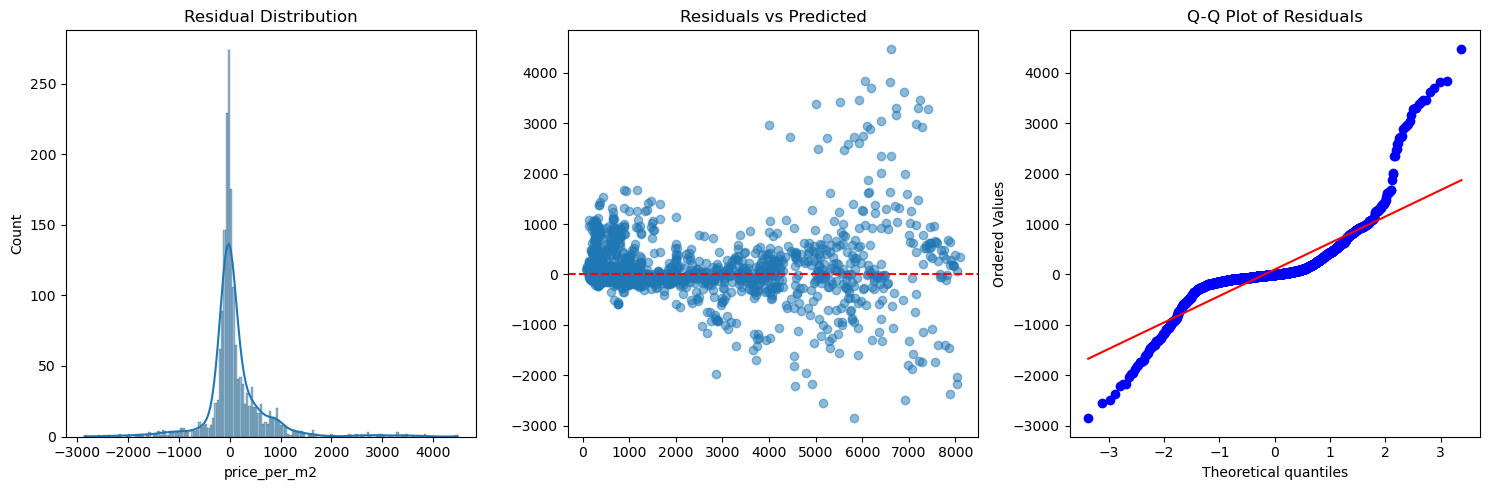


Calculating feature importance...


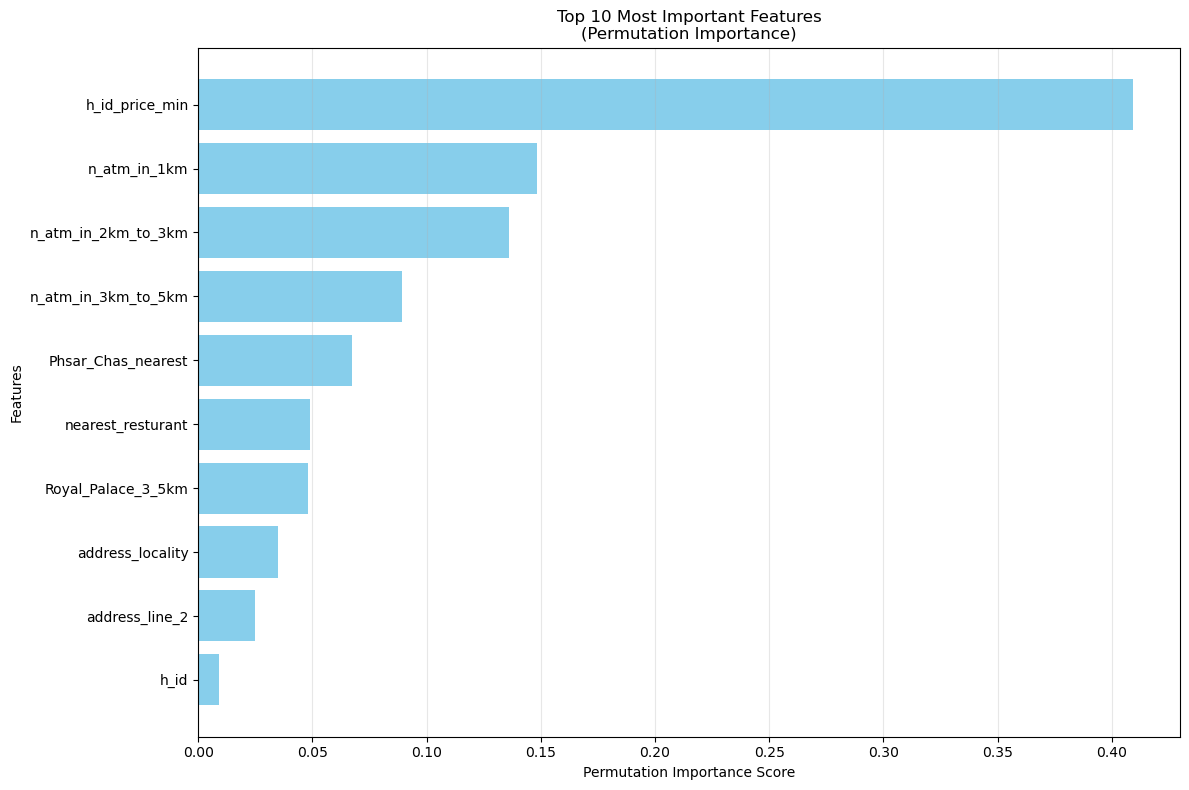

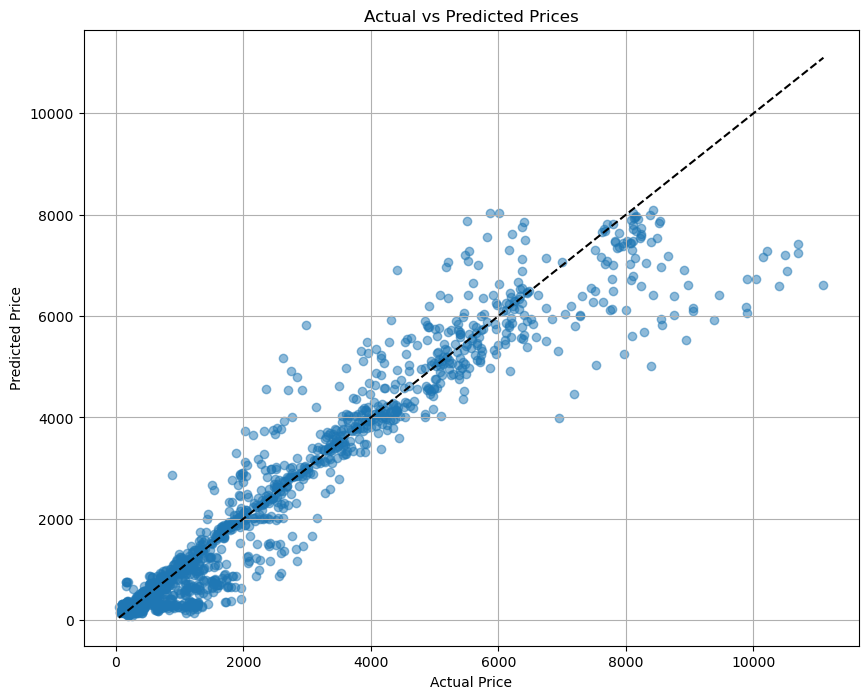


Evaluation complete! Results saved to:
- saved_model_residual_analysis.png
- saved_model_feature_importance.png
- saved_model_actual_vs_predicted.png


In [29]:
os.makedirs("model_evaluation", exist_ok=True)
    
# Load model and data
model, X_train, y_train, X_test, y_test, feature_names = load_model_and_data()

# Run evaluation
results = evaluate_saved_model(
    model, 
    X_train, 
    y_train, 
    X_test, 
    y_test, 
    feature_names
)

print("\nEvaluation complete! Results saved to:")
print("- saved_model_residual_analysis.png")
print("- saved_model_feature_importance.png")
print("- saved_model_actual_vs_predicted.png")